# **Financial Asset & Return Analysis**

In [1]:
import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yfin

from matplotlib import pyplot as plt
from scipy import stats

In [2]:
# Starting and end dates
start = datetime.date(2019, 8, 1)
end = datetime.date(2024, 8, 1)

df = pd.read_csv('stocks_return_data.csv', index_col='Date', parse_dates=True)\
                    .loc[start:end].reindex(columns=["^GSPC", "^IXIC", "BTC-USD"])

# Display the first five rows
df.head()

,^GSPC,^IXIC,BTC-USD
Date,,,
2019-08-01,2953.560059,8111.120117,10399.668945
2019-08-02,2932.050049,8004.069824,10518.174805
2019-08-03,NaN,NaN,10821.726562
2019-08-04,NaN,NaN,10970.184570
2019-08-05,2844.739990,7726.040039,11805.653320


I've retrieved the data from the two most popular U.S. indices, the NASDAQ and S&P 500, along with the daily Bitcoin prices from the last five years.

### **Calculating Log Returns, Remove Unused Columns, and Drop Nulls**

I removed the nulls for the weekend dates, calculated the log returns for the S&P 500, NASDAQ, and Bitcoin and removed the original price columns.

In [3]:
# Remove rows with missing values
df.dropna(inplace = True)

# Calculate log returns
df["SP500"] = np.log(df["^GSPC"]) - np.log(df["^GSPC"].shift(1))
df["NASDAQ"] = np.log(df["^IXIC"]) - np.log(df["^IXIC"].shift(1))
df["Bitcoin"] = np.log(df["BTC-USD"]) - np.log(df["BTC-USD"].shift(1))

# Remove original price columns
df.drop(["^GSPC", "^IXIC", "BTC-USD"], axis = 'columns', inplace = True)

# Remove rows with missing values (again)
df.dropna(inplace = True)

# Display the first five rows
df.head()

,SP500,NASDAQ,Bitcoin
Date,,,
2019-08-02,-0.007309,-0.013286,0.011331
2019-08-05,-0.030230,-0.035354,0.115474
2019-08-06,0.012933,0.013784,-0.028132
2019-08-07,0.000767,0.003767,0.039612
2019-08-08,0.018588,0.022178,0.002044


### **Show Summary Stats for the Index Returns**


In [4]:
df.describe()

,SP500,NASDAQ,Bitcoin
count,1257.000000,1257.000000,1257.000000
mean,0.000498,0.000616,0.001453
std,0.013458,0.015952,0.041542
min,-0.127652,-0.131492,-0.464730
25%,-0.005256,-0.006802,-0.016203
50%,0.000866,0.001270,0.000365
75%,0.007240,0.009293,0.020095
max,0.089683,0.089347,0.191527


## **Variance and Standard Deviation**

In [5]:
df.std()

,0
SP500,0.013458
NASDAQ,0.015952
Bitcoin,0.041542


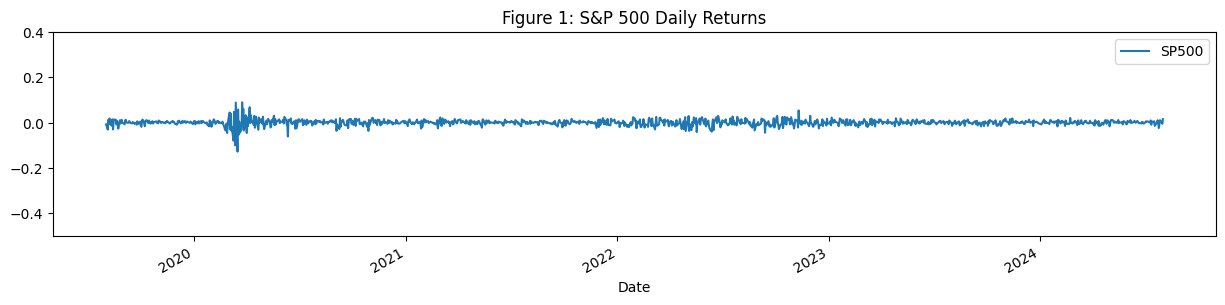

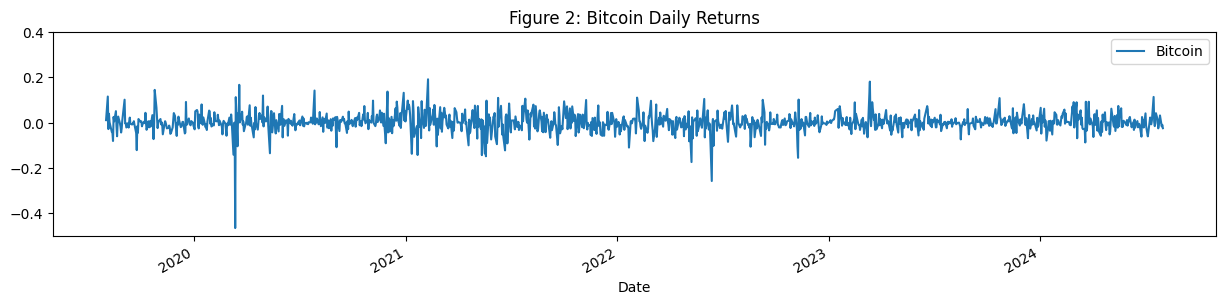

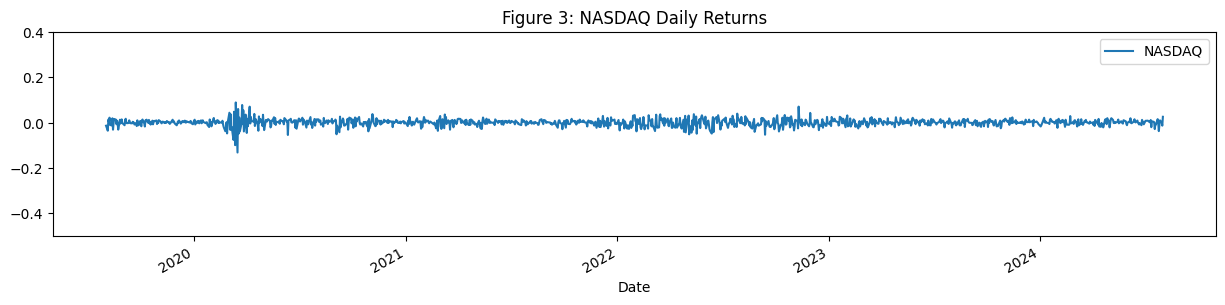

In [6]:
# Generate three plots
ax1 = df.plot(figsize=(15, 3), y="SP500", title="Figure 1: S&P 500 Daily Returns")
ax2 = df.plot(figsize=(15, 3), y="Bitcoin", title="Figure 2: Bitcoin Daily Returns")
ax3 = df.plot(figsize=(15, 3), y="NASDAQ", title="Figure 3: NASDAQ Daily Returns")

# Set y-axis limits for both plots
ax1.set_ylim(-0.5, 0.4)
ax2.set_ylim(-0.5, 0.4)
ax3.set_ylim(-0.5, 0.4);

The above charts show clearly how much more volatile Bitcoin is compared to the S&P 500 and the NASDAQ and hence why the variance/standard deviation of returns is much higher.

## **Covariance and Correlation**




### **Covariance Matrix**

In [7]:
df.cov()

,SP500,NASDAQ,Bitcoin
SP500,0.000181,0.000203,0.000200
NASDAQ,0.000203,0.000254,0.000253
Bitcoin,0.000200,0.000253,0.001726


All the values are positive, indicating a positive relationship between the returns of these assets. This means that when the return of one asset is positive, the return of the other assets tends to be positive as well.


### **Using the Pearson Correlation Coefficient Formula**


In [8]:
round(df.corr(), 3)

,SP500,NASDAQ,Bitcoin
SP500,1.000,0.947,0.358
NASDAQ,0.947,1.000,0.381
Bitcoin,0.358,0.381,1.000


And just like the covariance matrix, all of the variables have a positive relationship. Here, we can also see the strength of the relationships: the S&P 500 is strongly correlated with NASDAQ since we've obtained a 0.947 Pearson's correlation coefficient. The relationship between NASDAQ and Bitcoin is still positive but much weaker with a 0.381 Pearson's correlation coefficient.


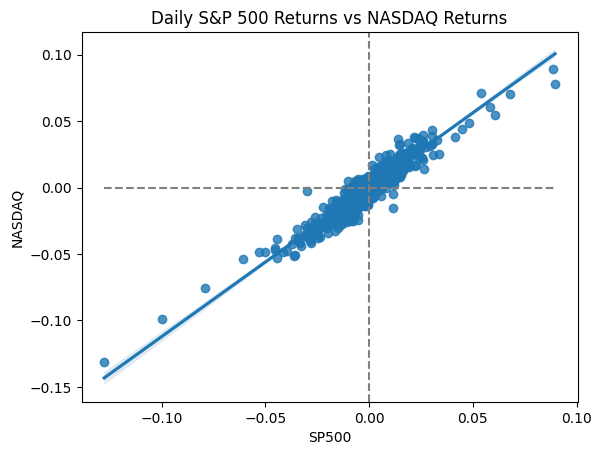

In [9]:
# Create scatter plot with regression line
chart = sns.regplot(x="SP500", y="NASDAQ", data=df).set(
    title="Daily S&P 500 Returns vs NASDAQ Returns"
)

# Add vertical line at x=0 and horizontal line at y=0
plt.axvline(0, 0, 1, dash_capstyle="butt", linestyle="--", color="grey")
plt.plot([min(df.SP500), max(df.SP500)], [0, 0], linestyle="--", color="grey");

This plot visually shows the relationship between the daily log returns of the S&P 500 and NASDAQ, including a regression line that represents the best-fit linear relationship between the two variables. The dashed lines at x=0 and y=0 help to visualize the positive and negative returns for each asset. This relationship shows nearly perfect correlation.

Now let's visualize relationship between S&P 500 and Bitcoin daily returns.

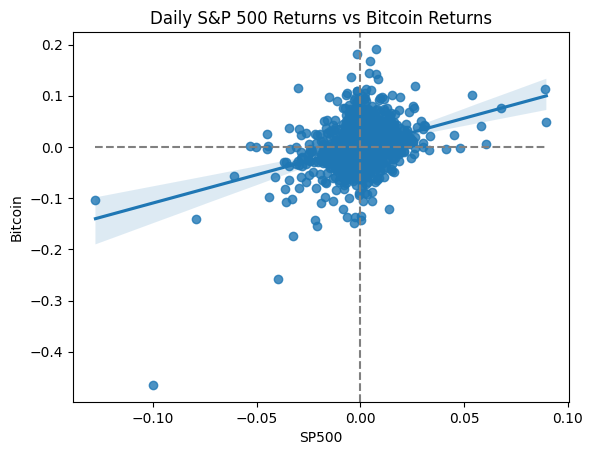

In [11]:
# Create scatter plot with regression line
sns.regplot(x="SP500", y="Bitcoin", data=df).set(
    title="Daily S&P 500 Returns vs Bitcoin Returns"
)

# Add vertical line at x=0 and horizontal line at y=0
plt.axvline(0, 0, 1, dash_capstyle="butt", linestyle="--", color="grey")
plt.plot([min(df.SP500), max(df.SP500)], [0, 0], linestyle="--", color="grey");

The relationship here is much more scattered even though the relationship is still slightly positive.

### **The Sharpe Ratio**

In [13]:
# Calculates the Sharpe Ratios for the S&P 500, NASDAQ and Bitcoin
Sharpe_Ratio_SP500 = df["SP500"].mean() / df["SP500"].std()
Sharpe_Ratio_NASDAQ = df["NASDAQ"].mean() / df["NASDAQ"].std()
Sharpe_Ratio_Bitcoin = df["Bitcoin"].mean() / df["Bitcoin"].std()

# Print the results
print("Sharpe Ratio of S&P 500: ", round(Sharpe_Ratio_SP500, 5))
print("Sharpe Ratio of NASDAQ: ", round(Sharpe_Ratio_NASDAQ, 5))
print("Sharpe Ratio of Bitcoin: ", round(Sharpe_Ratio_Bitcoin, 5))


Sharpe Ratio of S&P 500:  0.03699
Sharpe Ratio of NASDAQ:  0.03863
Sharpe Ratio of Bitcoin:  0.03498


Based on these results, the S&P 500 (0.03699) has a very similar Sharpe Ratio to the NASDAQ (0.03863) but slightly higher Sharpe Ratio compared to Bitcoin (0.03498). This suggests that the S&P 500 and the NASDAQ have provided a slightly better risk-adjusted return over the analyzed period.

One major flaw with the Sharpe ratio is that it uses the standard deviation of returns in the denominator, which assumes that returns are normally distributed. This may not always--and is actually rarely--the case.

## **Semivariance**

How can we refine the Sharpe ratio to give an even better measure of risk-adjusted returns? Semivariance is the answer. Semivariance, also known as downside risk, is a more refined version of a standard deviation. Standard deviation looks at both the upside and downside risk of an investment. Most investors, unless you're trading short, care much more about the downside risk than the upside risk.

Now let's compute semivariance for the three assets:


In [14]:
# Calculate the mean return for each
sp500mean = df["SP500"].mean()
NASDAQmean = df["NASDAQ"].mean()
BTCmean = df["Bitcoin"].mean()

# Calculate semivariance for each
sp500_semivariance = ((df[df["SP500"] < sp500mean]["SP500"] - sp500mean) ** 2).mean()
NASDAQ_semivariance = ((df[df["NASDAQ"] < NASDAQmean]["NASDAQ"] - NASDAQmean) ** 2).mean()
BTC_semivariance = ((df[df["Bitcoin"] < BTCmean]["Bitcoin"] - BTCmean) ** 2).mean()

# Print the semivariance results
print("Semivariance of S&P 500: ", round(sp500_semivariance, 5))
print("Semivariance of NASDAQ: ", round(NASDAQ_semivariance, 5))
print("Semivariance of Bitcoin: ", round(BTC_semivariance, 5))


Semivariance of S&P 500:  0.00021
Semivariance of NASDAQ:  0.0003
Semivariance of Bitcoin:  0.00181


This output shows that Bitcoin has a much higher semivariance (0.00181) compared to the S&P 500 (0.00021) and NASDAQ (0.0003). This indicates that Bitcoin has experienced significantly larger negative deviations from its average return, suggesting higher downside risk.

## **Stock Returns Distribution**
I looked at the distribution of the stock returns and to do this, I had to pull in more data and look at 20 years data.

In [15]:
# Starting and end dates
start = datetime.date(2004, 8, 1)
end = datetime.date(2024, 8, 1)

# Get data
prices = pd.read_csv('stocks_return_data.csv', index_col='Date', parse_dates=True)\
                    .loc[start:end].reindex(columns=["^GSPC"])

# Drop Nulls for weekend and rename column to make names more intuitive
prices.dropna(inplace = True)
prices = prices.rename(columns={"^GSPC": "SP500"})
df = np.log(prices) - np.log(prices.shift(1))
df = df.iloc[1:, 0:]

### **Are the Returns Symmetric?**

One quick way of doing this is to determine how many data points are on either side of the mean here. We have a bit more than 5,000 data points here. I need to get the percentage of data points greater than the mean.

In [16]:
len(df)

5033

In [17]:
# This takes the count of data points greater than the mean and divides it by the total number of data points.
(len(df[df.SP500 > df.SP500.mean()])) / (len(df))

0.5235446056030201

We're getting about 52.4% of data points being greater than the mean, which shows we have a slightly negative skew to this dataset. We can't rule out symmetric returns based on this since it is only a sample of data and is reasonably close to the 50% mark. This makes it hard to say for certain whether S&P 500 returns are symmetric or not, but it is still a reasonable assumption to make here.

### **Is Volatility Constant?**

The following code calculates and plots the rolling 50-day standard deviation of the S&P 500 log returns, providing a visualization of the volatility over time.

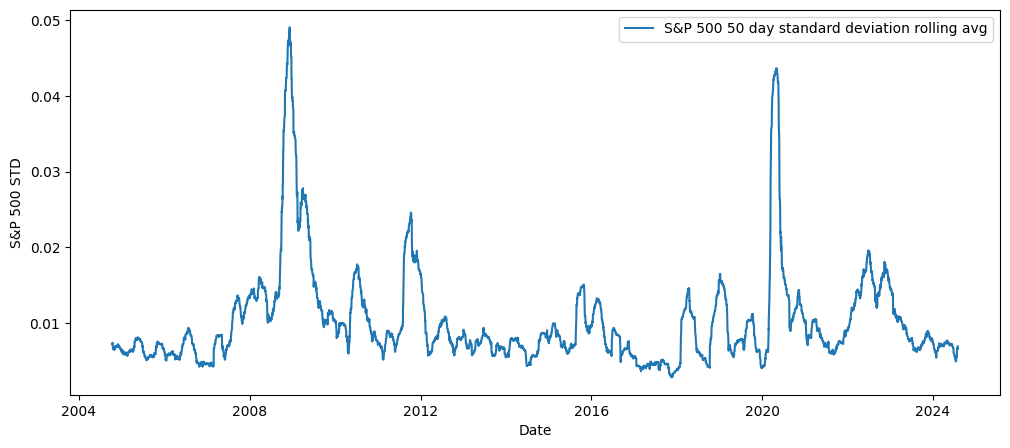

In [18]:
# Calculate rolling standard deviation
vols = pd.DataFrame(df.SP500.rolling(50).std()).rename(columns={"SP500": "S&P 500 STD"})

# set figure size and plot rolling standard deviations
plt.figure(figsize=(12, 5))
sns.lineplot(
    x="Date",
    y="S&P 500 STD",
    data=vols,
    label="S&P 500 50 day standard deviation rolling avg",
)
plt.show()

From the above plot, it can be clearly seen that volatility is not constant.

## **Are Stock Returns Normally Distributed?**

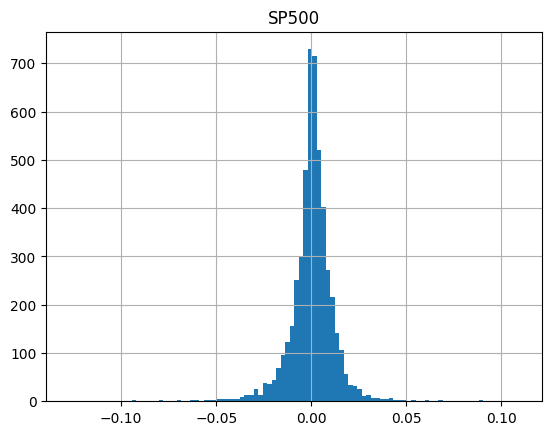

In [19]:
df.hist(bins=100);

The chart above looks like it could be normally distributed, but we need to be a little more scientific to determine if that's actually the case or not.

### **Conducting a Normality Test**

I used the `normaltest()` method to determine if the sample data could fit a normal distribution.

In [20]:
stats.normaltest((np.array(df.SP500)))

NormaltestResult(statistic=np.float64(1234.7310969195069), pvalue=np.float64(7.61288004534643e-269))

The output above shows the results of the normality test on the S&P 500 log return data. The statistic of 1234.73 is very high, indicating a substantial deviation from a normal distribution. The extremely small p-value (7.61e-269) provides strong evidence to reject the null hypothesis that the data is normally distributed. In simpler terms, this test strongly suggests that the S&P 500 daily log returns in our dataset do not follow a normal distribution.

### **Testing Skewness and Kurtosis**

I used the `jarque_bera()` method directly to the data to get the test statistic.


In [22]:
stats.jarque_bera((np.array(df.SP500)))

SignificanceResult(statistic=np.float64(36591.04252491935), pvalue=np.float64(0.0))

A small p-value (typically less than 0.05) indicates that the data is likely not normally distributed. This output indicates that the p-value from the Jarque-Bera test is 0.0 (or extremely close to zero). This strongly suggests that the S&P 500 daily log returns in the dataset are not normally distributed.

### **Where Does Our Gaussian Distribution Break Down?**

According to the normality test, our data is not normally distributed despite the histogram looking like it may be. The data failed the normality test likely because of the fat tails.

In [23]:
# minimum and maximum daily log returns
dfMax = df.SP500.max()
dfMin = df.SP500.min()

# Print maximum and minimum daily log returns
print("Maximum return of sample data is: ", round(dfMax, 5))
print("Minimum return of sample data is: ", round(dfMin, 5))
print(' - - - - - - - - - -')

# Calculates the number of standard deviations from the mean return
num_dev_max = (df.SP500.max() - df.SP500.mean()) / df.SP500.std()
num_dev_min = (df.SP500.min() - df.SP500.mean()) / df.SP500.std()

# Print num_dev_max and num_dev_min
print("Number of standard deviations from the mean for the maximum return: ", round(num_dev_max, 5))
print("Number of standard deviations from the mean for the minimum return: ", round(num_dev_min, 5))


Maximum return of sample data is:  0.10957
Minimum return of sample data is:  -0.12765
 - - - - - - - - - -
Number of standard deviations from the mean for the maximum return:  9.0497
Number of standard deviations from the mean for the minimum return:  -10.60025


This output provides valuable insights into the distribution of S&P 500 daily log returns, particularly highlighting the presence of outliers or fat tails:

 - Maximum and Minimum Returns: The maximum daily return of approximately 10.957% and the minimum daily return of approximately -12.765% show the range of returns observed in our data.
 - Z-scores: The z-scores for the maximum and minimum returns are 9.05 and -10.6, respectively. These are extremely high z-scores, indicating that both the maximum and minimum returns are significant outliers, far away from the mean in terms of standard deviations.



This information is crucial for risk management and modeling, as relying on the assumption of normality can lead to underestimating the probability of extreme events and potential losses.


Going further with this idea, based on normal distribution z tables, we would expect 99.7% of our data points to be within +/- 3 standard deviations from the mean.

Let's determine this for the sample data.

In [24]:
# Calculates the upper and lowers bounds
upper = (3 * df.SP500.std()) + df.SP500.mean()
lower = (-3 * df.SP500.std()) + df.SP500.mean()

# Print the results
print("Upper bound: ", round(upper, 5))
print("Lower bound: ", round(lower, 5))


Upper bound:  0.03654
Lower bound:  -0.0359


In [25]:
len(df)

5033

The above two calculations would imply that 99.7% of all of our data points should be in between -0.0359 and 0.03654.

Since we have 5,033 data points, we would expect about 15 (i.e., .03% of 5,033) of them to be outside of that range if normality was held.

In [26]:
# Calculates the number of data points
len(df[(df["SP500"] < lower) | (df["SP500"] > upper)])


84

That's a significant number of outliers considering that in a normal distribution, you would expect only about 0.3% of the data points to fall outside the range defined by 3 standard deviations from the mean.

This finding further supports the conclusion from the normality tests that the S&P 500 daily log returns are not normally distributed and exhibit fat tails. The presence of these outliers highlights the importance of considering alternative distributions and risk measures when modeling and analyzing financial data.

## **Non-Gaussian Distributions**

One potential alternative distribution we could use to forecast stock returns is the Student's t-distribution. This is very similar to a normal distribution except it has heavier tails.

Let's proceed with a visual inspection of the distribution of our data by superimposing the normal distribution on the kernel density estimation (KDE) of S&P 500 returns:

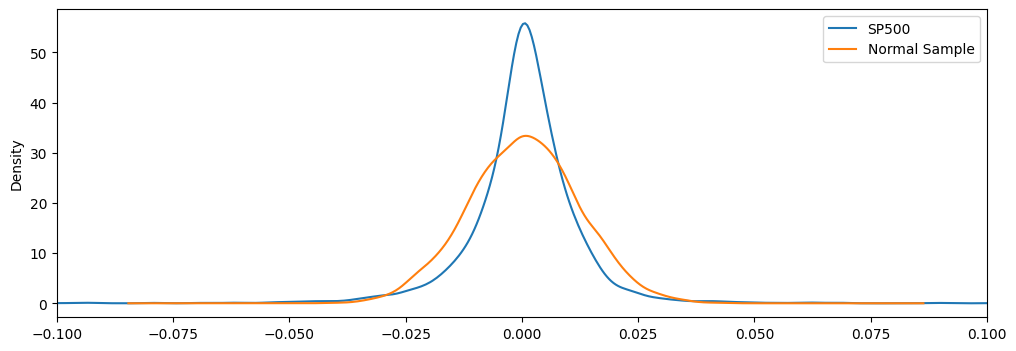

In [28]:
# Sampling from normal distribution
np.random.seed(222)
normal_dist = stats.norm.rvs(size=len(df["SP500"]), loc = df["SP500"].mean(), scale = df["SP500"].std())

# Creating an additional column in df in order to use the KDE plot functionality of pandas
df['Normal Sample'] = normal_dist

# Plotting the KDE plots
df[['SP500', 'Normal Sample']].plot(kind = 'kde', xlim = (-0.1, 0.1), figsize = (12,4));


The S&P 500 returns seem a lot more leptokurtic.


In [29]:
df.SP500.kurt()

np.float64(13.18083916908493)

Indeed, the kurtosis of the S&P 500 is significantly greater than 3, confirming that the distribution of S&P 500 daily log returns is highly leptokurtic.


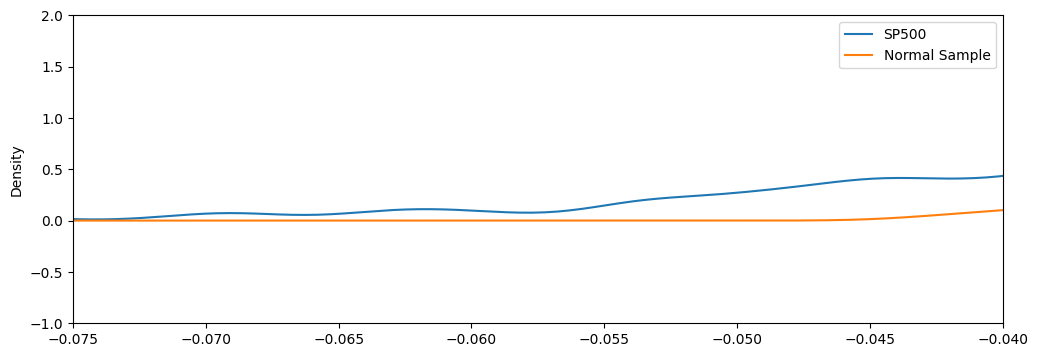

In [30]:
# Observing the tails
df[['SP500', 'Normal Sample']].plot(kind = 'kde', xlim = (-0.075, -0.04), ylim = (-1, 2), figsize = (12,4));

The resulting plot visually shows the differences in the tails of the two distributions. We observe that the actual S&P 500 returns have a fatter left tail than the normal distribution, indicating a higher probability of large negative returns. This visualization provides further evidence of the non-normality of the S&P 500 returns and the presence of fat tails.

At this stage, I calibrated the parameters of the Student's t-distribution using Maximum Likelihood Estimation (MLE) to align the distribution closely with the observed data.


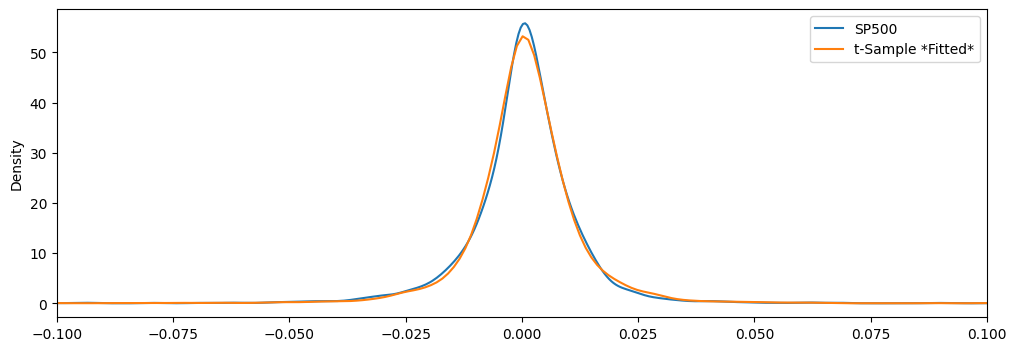

In [31]:
# Fit the t-distribution using MLE
params = stats.t.fit(df.SP500)

# We plot the fitted distribution against the kde of the data
df['t-Sample *Fitted*'] = stats.t.rvs(*params, size = len(df))
df[['SP500', 't-Sample *Fitted*']].plot(kind = 'kde', figsize = (12,4), xlim = (-0.1, 0.1));

From the visual inspection, it's evident that the synthetic data generated from the fitted Student's t-distribution offers a more accurate approximation of our actual data compared to what we get from a normal distribution.

Let's check the tails once more.

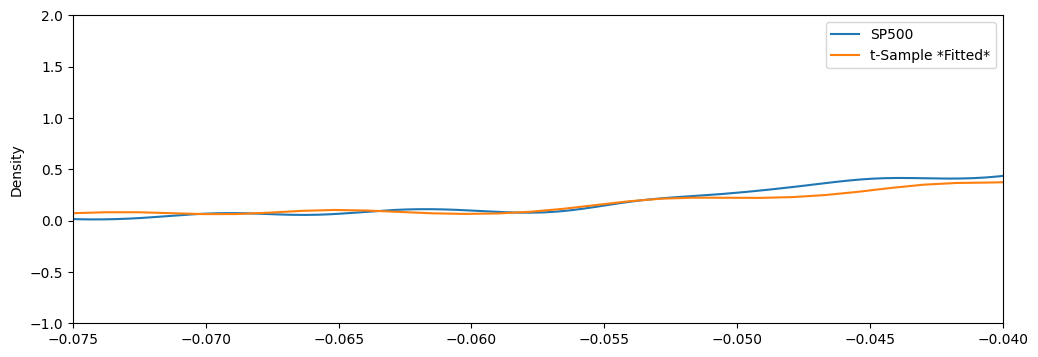

In [32]:
# Plot left tail area
df[['SP500', 't-Sample *Fitted*']].plot(kind = 'kde', figsize = (12,4), xlim = (-0.075, -0.04), ylim = (-1, 2));

This time, the tails seem to be better explained by the t-distribution. Here, we can observe that the fitted t-distribution captures the fat tail of the S&P 500 returns more accurately than the normal distribution. This further demonstrates the suitability of the t-distribution for modeling financial data that exhibits fat tails and the potential for extreme events.